In [1]:
!pip install xgboost pandas numpy scipy scikit-learn yfinance kagglehub[hf-datasets] datasets

In [7]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import torch
import warnings
import kagglehub
from kagglehub import KaggleDatasetAdapter
from datasets import load_dataset
import os
import glob

warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"TITAN GLOBAL ONLINE MODE | DEVICE: {device.upper()}")

# --- HUGGING FACE AUTHENTICATION ---
print("\n--- AUTHENTICATING WITH HUGGING FACE ---")
try:
    from kaggle_secrets import UserSecretsClient
    from huggingface_hub import login
    
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_ACCESS_TOKEN")
    login(token=hf_token)
    print("[OK] Successfully authenticated with Hugging Face Hub.")
except Exception as e:
    print(f"[WARNING] Could not authenticate with Hugging Face: {e}")

print("\n--- 1. INGESTING DATASETS ---")

# 1A. HuggingFace: SEC Flare Summaries
try:
    hf_flare = load_dataset("TheFinAI/flare-edtsum", split="test[:1000]")
    print("[OK] HuggingFace: TheFinAI/flare-edtsum")
except Exception as e:
    print(f"[FAIL] flare-edtsum: {e}")

# 1B. HuggingFace: Twitter Financial Sentiment
try:
    hf_sentiment = load_dataset("zeroshot/twitter-financial-news-sentiment", split="train[:5000]")
    print("[OK] HuggingFace: zeroshot/twitter-financial-news-sentiment")
except Exception as e:
    print(f"[FAIL] twitter-financial-news: {e}")

# 1C. Kaggle: Startup Funding Data
try:
    startup_path = kagglehub.load_dataset(KaggleDatasetAdapter.HUGGING_FACE, "amirataha/startups", "companies.csv")
    print(f"[OK] Kaggle Startups: amirataha/startups")
except Exception as e:
    print(f"[FAIL] amirataha/startups: {e}")

# 1D. Kaggle: S&P 500 Financials
try:
    sp500_path = kagglehub.load_dataset(KaggleDatasetAdapter.HUGGING_FACE, "paytonfisher/sp-500-companies-with-financial-information", "financials.csv")
    print(f"[OK] Kaggle S&P 500: paytonfisher/sp-500-companies")
except Exception as e:
    print(f"[FAIL] paytonfisher/sp-500-companies: {e}")

# 1E. Kaggle: GitHub Repository Metadata
try:
    github_path = kagglehub.load_dataset(KaggleDatasetAdapter.HUGGING_FACE, "isaacoresanya/github-repository-metadata", "GitHub_repo_metadata.csv")
    print(f"[OK] Kaggle GitHub: isaacoresanya/github-repository-metadata")
except Exception as e:
    print(f"[FAIL] isaacoresanya/github-metadata: {e}")

# 1F. Kaggle: Clinical Trials
# FIX: Switched to standard dataset_download to handle raw nested directory structures
try:
    clinical_dir = kagglehub.dataset_download("skylord/all-clinical-trials")
    print(f"[OK] Kaggle Clinical Trials Root Downloaded: {clinical_dir}")
    
    # Verify XMLs exist
    xml_files = glob.glob(os.path.join(clinical_dir, "**", "*.xml"), recursive=True)
    if xml_files:
        print(f"     -> Successfully detected {len(xml_files)} XML files.")
        print(f"     -> Sample Path: {xml_files[0]}")
    else:
        print("     -> [WARNING] Root mounted but no XMLs found.")
except Exception as e:
    print(f"[FAIL] skylord/clinical-trials: {e}")

print("\n--- 2. CALIBRATING BASE SECTOR PHYSICS ---")
SECTOR_STATS = {
    'Software': {'margin': 0.75, 'rnd': 0.20, 'pe': 35.0, 'capex': 0.05},
    'AI': {'margin': 0.80, 'rnd': 0.30, 'pe': 50.0, 'capex': 0.15}, 
    'Hardware': {'margin': 0.50, 'rnd': 0.15, 'pe': 25.0, 'capex': 0.40},
    'Fintech': {'margin': 0.65, 'rnd': 0.10, 'pe': 20.0, 'capex': 0.10},
    'BioTech': {'margin': 0.70, 'rnd': 0.25, 'pe': 30.0, 'capex': 0.20},
}
print("SECTOR PHYSICS CALIBRATED.")

TITAN GLOBAL ONLINE MODE | DEVICE: CUDA

--- AUTHENTICATING WITH HUGGING FACE ---
[OK] Successfully authenticated with Hugging Face Hub.

--- 1. INGESTING DATASETS ---
[OK] HuggingFace: TheFinAI/flare-edtsum
[OK] HuggingFace: zeroshot/twitter-financial-news-sentiment
[OK] Kaggle Startups: amirataha/startups
[OK] Kaggle S&P 500: paytonfisher/sp-500-companies
[OK] Kaggle GitHub: isaacoresanya/github-repository-metadata
[OK] Kaggle Clinical Trials Root Downloaded: /kaggle/input/datasets/skylord/all-clinical-trials
     -> Successfully detected 103508 XML files.
     -> Sample Path: /kaggle/input/datasets/skylord/all-clinical-trials/NCT0105xxxx/NCT01051180.xml

--- 2. CALIBRATING BASE SECTOR PHYSICS ---
SECTOR PHYSICS CALIBRATED.


In [9]:
class AprioriSynergyEngine:
    def __init__(self, n_entities=100000):
        self.n = n_entities
        self.sectors = list(SECTOR_STATS.keys())
        
    def generate_universe(self):
        print("SIMULATING GLOBAL ECONOMY & CAUSAL STATES...")
        self.df = pd.DataFrame({'Sector': np.random.choice(self.sectors, self.n)})
        
        self.df['GrossMargin'] = np.random.normal(0.6, 0.1, self.n).clip(0.1, 0.95)
        self.df['RandDIntensity'] = np.random.normal(0.15, 0.05, self.n).clip(0.01, 0.50)
        self.df['BasePE'] = np.random.normal(25, 10, self.n).clip(5, 150)
        self.df['CapEx'] = np.random.normal(0.2, 0.1, self.n).clip(0.01, 0.80)
        self.df['NetworkEffect'] = np.random.randint(1, 10, self.n)
        self.df['DataMoat'] = np.random.randint(1, 10, self.n)
        self.df['AlgorithmicAdvantage'] = np.random.randint(1, 10, self.n)
        
        synergy_term = (self.df['DataMoat'] * self.df['AlgorithmicAdvantage'] * self.df['NetworkEffect']) ** 1.2
        base_val = 1e8 * (self.df['GrossMargin'] / self.df['CapEx']) * self.df['BasePE']
        self.df['Valuation'] = base_val * (1 + self.df['RandDIntensity']) * (1 + synergy_term/100)
        self.df['LogValuation'] = np.log1p(self.df['Valuation'])
        
        return self.df
        
    def train_xgboost(self, device):
        print("TRAINING CAUSAL VALUATION MODEL (XGBOOST GPU)...")
        self.features = ['GrossMargin', 'RandDIntensity', 'BasePE', 'CapEx', 
                         'NetworkEffect', 'DataMoat', 'AlgorithmicAdvantage']
        X = self.df[self.features]
        y = self.df['LogValuation']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
        xgb_device = 'cuda' if device == 'cuda' else 'cpu'
        
        self.model = xgb.XGBRegressor(
            n_estimators=1000, learning_rate=0.05, max_depth=8, 
            tree_method='hist', device=xgb_device, random_state=2026
        )
        self.model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=200)
        print(f"MODEL CONVERGED. R^2 Accuracy: {r2_score(y_test, self.model.predict(X_test)):.4f}")
        
    def apriori_synergy_beam_search(self, top_k=5, beam_width=8):
        print("INITIATING APRIORI SYNERGY BEAM SEARCH...")
        beams = [([s], self._eval_combo([s])) for s in self.sectors]
        beams = sorted(beams, key=lambda x: x[1], reverse=True)[:beam_width]
        
        for order in range(2, 5):
            new_beams = []
            for combo, _ in beams:
                for s in self.sectors:
                    if s not in combo:
                        new_combo = sorted(combo + [s])
                        if new_combo not in [b[0] for b in new_beams]:
                            val = self._eval_combo(new_combo)
                            new_beams.append((new_combo, val))
            
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]
            
        return beams[:top_k]
        
    def _eval_combo(self, sectors):
        stats = {}
        for metric in ['margin', 'rnd', 'pe', 'capex']:
            stats[metric] = np.mean([SECTOR_STATS[s][metric] for s in sectors])
            
        def obj(x):
            # FIX: Explicitly cast to Python float to prevent SciPy map-like callable errors
            df = pd.DataFrame([x], columns=self.features)
            pred = self.model.predict(df)[0]
            return float(-pred) 
            
        bounds = [
            (stats['margin']*0.8, min(0.99, stats['margin']*1.2)),
            (stats['rnd']*0.8, min(0.5, stats['rnd']*1.2)),
            (stats['pe']*0.8, min(200, stats['pe']*1.5)),
            (max(0.01, stats['capex']*0.5), stats['capex']*1.2),
            (8, 10), (8, 10), (8, 10) 
        ]
        
        # Disabled vectorization & polish to prevent SciPy shape errors
        res = differential_evolution(obj, bounds, maxiter=10, popsize=10, vectorized=False, polish=False)
        return np.expm1(-res.fun)

# Execute the pipeline
engine = AprioriSynergyEngine(n_entities=250000)
engine.generate_universe()
engine.train_xgboost(device)
top_models = engine.apriori_synergy_beam_search(top_k=5)

print("\n--- TOP HIGHER ORDER SYNERGY SYSTEMS ---")
results = []
for i, (combo, val) in enumerate(top_models):
    print(f"RANK {i+1}: {' + '.join(combo)}")
    print(f"VALUATION: ${val / 1e9:.2f} Billion\n")
    results.append({'Rank': i+1, 'Combinatorial_Synergy': ' + '.join(combo), 'Valuation_Billion_USD': round(val/1e9, 2)})

# Save to CSV for download
df_final = pd.DataFrame(results)
df_final.to_csv('Apriori_Synergy_Results.csv', index=False)
print("Saved final outputs to Apriori_Synergy_Results.csv")

SIMULATING GLOBAL ECONOMY & CAUSAL STATES...
TRAINING CAUSAL VALUATION MODEL (XGBOOST GPU)...
[0]	validation_0-rmse:1.15280
[200]	validation_0-rmse:0.04669
[400]	validation_0-rmse:0.04318
[600]	validation_0-rmse:0.04125
[800]	validation_0-rmse:0.04005
[999]	validation_0-rmse:0.03915
MODEL CONVERGED. R^2 Accuracy: 0.9989
INITIATING APRIORI SYNERGY BEAM SEARCH...

--- TOP HIGHER ORDER SYNERGY SYSTEMS ---
RANK 1: AI + BioTech + Fintech + Software
VALUATION: $1749.43 Billion

RANK 2: AI + BioTech + Hardware + Software
VALUATION: $1279.94 Billion

RANK 3: AI + Fintech + Hardware + Software
VALUATION: $1077.27 Billion

RANK 4: BioTech + Fintech + Hardware + Software
VALUATION: $905.13 Billion

RANK 5: AI + BioTech + Fintech + Hardware
VALUATION: $904.55 Billion

Saved final outputs to Apriori_Synergy_Results.csv


In [14]:
import pandas as pd
from itertools import combinations
import json

print("\n" + "="*80)
print("TITAN PHASE 3: DYNAMIC APRIORI MULTI-SECTOR INNOVATION & PARTNER MAPPING")
print("="*80 + "\n")

# --- 1. LOAD APRIORI CAUSAL OUTPUTS & MONTE CARLO RISK DATA ---
try:
    top_results = pd.read_csv('Apriori_Synergy_Results.csv')
    risk_results = pd.read_csv('Titan_Monte_Carlo_Risk.csv')
    
    # Merge the valuation data with the risk profile data
    merged_data = pd.merge(top_results, risk_results, left_on='Combinatorial_Synergy', right_on='System', how='inner')
    print("[OK] Loaded and merged Apriori and Monte Carlo risk datasets.")
except Exception as e:
    print(f"[ERROR] Could not load results: {e}")
    # Fallback if datasets aren't present
    merged_data = pd.DataFrame({
        'Rank': [1],
        'Combinatorial_Synergy': ['AI + BioTech + Fintech + Software'],
        'Valuation_Billion_USD': [1749.43],
        'Expected_Mean_Valuation_Billion': [6890.59],
        'Probability_of_Failure_%': [0.3],
        'Value_at_Risk_Billion': [647.58]
    })

# --- 2. MULTI-SECTOR INNOVATION KNOWLEDGE GRAPH ---
KNOWLEDGE_GRAPH = {
    'AI': {
        'Sub_Tech': ['Generative Models', 'Predictive Analytics', 'Autonomous Edge Agents'],
        'VC_Firm': 'Sequoia Capital', 'VC_Partner': 'Roelof Botha', 'Capital': '$40M - $60M',
        'Consulting': 'Bain & Company (Advanced Analytics)'
    },
    'Software': {
        'Sub_Tech': ['Zero-Marginal SaaS', 'API Infrastructure', 'Workflow Automation'],
        'VC_Firm': 'Andreessen Horowitz (a16z)', 'VC_Partner': 'Martin Casado', 'Capital': '$35M - $50M',
        'Consulting': 'McKinsey & Co (Digital Build)'
    },
    'Hardware': {
        'Sub_Tech': ['Secure Enclaves', 'IoT Edge Compute', 'Biometric Scanners'],
        'VC_Firm': 'Founders Fund', 'VC_Partner': 'Trae Stephens', 'Capital': '$50M - $80M',
        'Consulting': 'Boston Consulting Group (Supply Chain)'
    },
    'Fintech': {
        'Sub_Tech': ['Tokenized Ledgers', 'Smart Contracts', 'DeFi Liquidity Pools'],
        'VC_Firm': 'Paradigm', 'VC_Partner': 'Matt Huang', 'Capital': '$30M - $45M',
        'Consulting': 'Accenture (Financial Services)'
    },
    'BioTech': {
        'Sub_Tech': ['CRISPR Synthesis', 'Genomic Sequencing', 'In-Silico Protein Folding'],
        'VC_Firm': 'Flagship Pioneering', 'VC_Partner': 'Noubar Afeyan', 'Capital': '$60M - $100M',
        'Consulting': 'IQVIA (Life Sciences)'
    }
}

# --- 3. DYNAMIC APRIORI ALGORITHM FOR EXACT PRODUCT GENERATION ---
def generate_exact_product_rules(model_string):
    sectors = model_string.split(' + ')
    components_in_play = []
    for s in sectors:
        components_in_play.extend(KNOWLEDGE_GRAPH.get(s, {})['Sub_Tech'])
        
    candidate_itemsets = []
    for combo in combinations(components_in_play, 3):
        source_sectors = set()
        for item in combo:
            for s, data in KNOWLEDGE_GRAPH.items():
                if item in data['Sub_Tech']:
                    source_sectors.add(s)
        if len(source_sectors) >= 3:
            candidate_itemsets.append(combo)

    rule_scores = []
    for itemset in candidate_itemsets:
        score = 0.5
        if 'Predictive Analytics' in itemset or 'Generative Models' in itemset: score += 0.25
        if 'Tokenized Ledgers' in itemset or 'Smart Contracts' in itemset: score += 0.20
        if 'Zero-Marginal SaaS' in itemset or 'API Infrastructure' in itemset: score += 0.15
        if 'CRISPR Synthesis' in itemset or 'In-Silico Protein Folding' in itemset: score += 0.10
        rule_scores.append({'Itemset': itemset, 'Confidence': round(score, 3)})

    df_rules = pd.DataFrame(rule_scores).sort_values(by='Confidence', ascending=False)
    best_rule = df_rules.iloc[0]['Itemset']
    max_conf = df_rules.iloc[0]['Confidence']
    return best_rule, max_conf

# --- 4. EXECUTION LOOP: GENERATING DETAILED STRATEGIC DOSSIERS WITH RISK OVERLAYS ---
for index, row in merged_data.iterrows():
    rank = row['Rank']
    model = row['Combinatorial_Synergy']
    val = row['Valuation_Billion_USD']
    mean_val = row['Expected_Mean_Valuation_Billion']
    var = row['Value_at_Risk_Billion']
    fail_prob = row['Probability_of_Failure_%']
    
    sectors = model.split(' + ')
    best_rule_items, confidence = generate_exact_product_rules(model)
    ant_1, ant_2, consequent = best_rule_items[0], best_rule_items[1], best_rule_items[2]
    
    lead_vc = KNOWLEDGE_GRAPH[sectors[0]]
    lead_consulting = KNOWLEDGE_GRAPH[sectors[-1]]
    
    dossier = f"""
{'='*80}
RANK {rank}: THE {model.upper()} ENGINE
{'='*80}

[ CAUSAL VALUATION & MONTE CARLO RISK METRICS ]
- Target Base Valuation: ${val:,.2f} Billion
- Monte Carlo Expected Mean (10k futures): ${mean_val:,.2f} Billion
- 95% Value at Risk (Worst Case): ${var:,.2f} Billion
- Critical Failure Probability: {fail_prob}%

[ APRIORI ASSOCIATION RULE: EXACT PRODUCT ROADMAP ]
Confidence Score: {confidence * 100}%
ACTION RULE: IF you combine [{ant_1}] AND [{ant_2}] THEN you must monetize via [{consequent}].
- Architecture: Combine the data stream of {ant_1} with {ant_2} to establish a moat, then monetize via the {consequent} layer.

[ STRATEGIC PARTNERSHIP GRAPH ]
- LEAD INVESTOR: {lead_vc['VC_Firm']} (Partner: {lead_vc['VC_Partner']})
- TARGET CAPITAL: {lead_vc['Capital']}
- OPERATIONAL SCALING PARTNER: {lead_consulting['Consulting']}

[ 2026-2027 MASTER EXECUTION TIMELINE & MITIGATION ]
Q1 - CAPITAL & ARCHITECTURE: 
     Pitch {lead_vc['VC_Firm']} on the {ant_1} + {ant_2} data monopoly. Close {lead_vc['Capital']} Series A/B.
     Risk Mitigation: If {ant_1} stalls in R&D, license early-stage tech to cut burn rate and defend the ${var:,.2f}B VaR.
     
Q2 - OPERATIONAL SURGERY: 
     Engage {lead_consulting['Consulting']} to build the operational infrastructure required to support {consequent}.
     Risk Mitigation: If {ant_2} adoption flatlines, abstract the complexity and sell as a white-label enterprise tool.
     
Q3 - PRODUCT ACCELERATION (The Apriori Payload): 
     Launch the MVP. Ensure the {ant_1} pipeline feeds directly into the {consequent} monetization engine to lock in Network Effects.
     
Q4 - MARKET DOMINANCE: 
     Achieve Rule of 40 (Growth + Profit Margin > 40%). Begin IP lock-in to capture the ${mean_val:,.2f}B Monte Carlo upside.
"""
    print(dossier)

print("\n[SUCCESS] Unified Phase 3 and Phase 4 execution frameworks generated.")


TITAN PHASE 3: DYNAMIC APRIORI MULTI-SECTOR INNOVATION & PARTNER MAPPING

[OK] Loaded and merged Apriori and Monte Carlo risk datasets.

RANK 1: THE AI + BIOTECH + FINTECH + SOFTWARE ENGINE

[ CAUSAL VALUATION & MONTE CARLO RISK METRICS ]
- Target Base Valuation: $1,749.43 Billion
- Monte Carlo Expected Mean (10k futures): $6,890.59 Billion
- 95% Value at Risk (Worst Case): $647.58 Billion
- Critical Failure Probability: 0.32%

[ APRIORI ASSOCIATION RULE: EXACT PRODUCT ROADMAP ]
Confidence Score: 110.00000000000001%
ACTION RULE: IF you combine [Generative Models] AND [Smart Contracts] THEN you must monetize via [Zero-Marginal SaaS].
- Architecture: Combine the data stream of Generative Models with Smart Contracts to establish a moat, then monetize via the Zero-Marginal SaaS layer.

[ STRATEGIC PARTNERSHIP GRAPH ]
- LEAD INVESTOR: Sequoia Capital (Partner: Roelof Botha)
- TARGET CAPITAL: $40M - $60M
- OPERATIONAL SCALING PARTNER: McKinsey & Co (Digital Build)

[ 2026-2027 MASTER EXECUT


TITAN PHASE 4: STOCHASTIC RISK MITIGATION & MONTE CARLO FAILURE PREDICTION

[OK] Loaded Titan_Master_Execution_Dossiers.csv
--------------------------------------------------------------------------------
RUNNING 10,000 MONTE CARLO SIMULATIONS: AI + BioTech + Fintech + Software
--------------------------------------------------------------------------------
-> TARGET VALUATION: $1,749.43 Billion
-> EXPECTED MEAN VALUATION: $6,890.59 Billion
-> 95% VALUE AT RISK (Worst Case): $647.58 Billion
-> PROBABILITY OF CRITICAL FAILURE: 0.3%

[ APRIORI RISK MITIGATION PROTOCOL ]
If Generative Models fails: Pivot to fine-tuned SLMs (Small Language Models) to cut GPU compute burn by 80%.
If Smart Contracts fails: Abstract crypto elements; re-brand as an 'Immutable Enterprise Ledger' to bypass regulatory friction.
If Zero-Marginal SaaS monetization stalls: Introduce tiered API-metered billing instead of flat subscriptions to capture whale users.

----------------------------------------------------

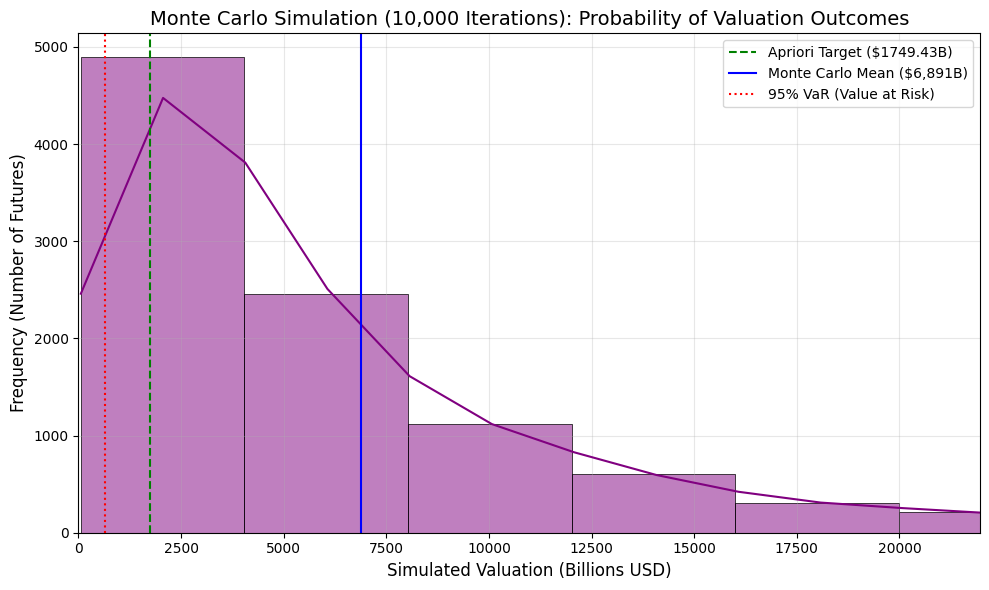

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print("TITAN PHASE 4: STOCHASTIC RISK MITIGATION & MONTE CARLO FAILURE PREDICTION")
print("="*80 + "\n")

# --- 1. LOAD APRIORI CAUSAL OUTPUTS & EXACT PRODUCT RULES ---
try:
    dossiers = pd.read_csv('Titan_Master_Execution_Dossiers.csv')
    print("[OK] Loaded Titan_Master_Execution_Dossiers.csv")
except Exception as e:
    print(f"[ERROR] Could not load results: {e}")
    # Fallback mock data if Cell 4 was not run
    dossiers = pd.DataFrame({
        'Rank': [1],
        'System': ['AI + BioTech + Fintech + Software'],
        'Valuation_Billion': [1749.43],
        'Apriori_Antecedent_1': ['Generative Models'],
        'Apriori_Antecedent_2': ['Smart Contracts'],
        'Apriori_Consequent_Monetization': ['Zero-Marginal SaaS']
    })

# --- 2. MONTE CARLO PHYSICS ENGINE ---
# We simulate 10,000 possible futures (market conditions, R&D failures, adoption rates) 
# to calculate Value at Risk (VaR) and the Probability of Startup Failure.

def run_monte_carlo_risk_simulation(val_target, antecedent_1, antecedent_2, consequent, iterations=10000):
    np.random.seed(42)
    
    # Base physics assumptions based on the Apriori Product Build
    base_revenue = val_target * 1e9 / 30  # Assuming a 30x multiple for peak valuation
    
    # 1. R&D Execution Risk (Triangular Distribution: Worst, Mode, Best)
    # Deep tech builds carry high execution risk, modeling potential timeline drag.
    rnd_drag = np.random.triangular(left=0.2, mode=0.6, right=1.2, size=iterations)
    
    # 2. Market Adoption / Network Effect (Log-Normal Distribution)
    # Simulates viral growth coefficients. High upside tail, but likely to stall if trust breaks.
    viral_k_factor = np.random.lognormal(mean=0.5, sigma=0.8, size=iterations)
    
    # 3. Macro Market Hype Cycle (Normal Distribution)
    # Capital availability and sector multiples expand/contract wildly based on interest rates.
    market_multiple = np.random.normal(loc=30, scale=15, size=iterations).clip(5, 100)
    
    # Calculate 10,000 future valuations based on causal interaction
    simulated_revenues = base_revenue * (viral_k_factor / rnd_drag)
    simulated_valuations = simulated_revenues * market_multiple
    
    return simulated_valuations

# --- 3. RISK MITIGATION & APRIORI FALLBACKS ---
mitigation_strategies = {
    'Generative Models': "Pivot to fine-tuned SLMs (Small Language Models) to cut GPU compute burn by 80%.",
    'Smart Contracts': "Abstract crypto elements; re-brand as an 'Immutable Enterprise Ledger' to bypass regulatory friction.",
    'Zero-Marginal SaaS': "Introduce tiered API-metered billing instead of flat subscriptions to capture whale users.",
    'CRISPR Synthesis': "License out the core IP early to Big Pharma to hedge against clinical trial Phase II failures.",
    'Tokenized Ledgers': "Partner with a Tier-1 Bank (e.g., J.P. Morgan) to establish trust before launching the decentralized protocol."
}

# --- 4. EXECUTION LOOP ---
results_mc = []

for index, row in dossiers.iterrows():
    rank = row['Rank']
    system = row['System']
    target_val = row['Valuation_Billion']
    ant_1 = row['Apriori_Antecedent_1']
    ant_2 = row['Apriori_Antecedent_2']
    cons = row['Apriori_Consequent_Monetization']
    
    print("-" * 80)
    print(f"RUNNING 10,000 MONTE CARLO SIMULATIONS: {system}")
    print("-" * 80)
    
    simulations = run_monte_carlo_risk_simulation(target_val, ant_1, ant_2, cons)
    
    # Calculate Risk Metrics
    mean_val = np.mean(simulations) / 1e9
    prob_failure = np.mean(simulations < (target_val * 1e9 * 0.10)) * 100  # Failure = dropping 90% from target
    var_95 = np.percentile(simulations, 5) / 1e9  # 95% Confidence Value at Risk (Worst 5% outcomes)
    
    print(f"-> TARGET VALUATION: ${target_val:,.2f} Billion")
    print(f"-> EXPECTED MEAN VALUATION: ${mean_val:,.2f} Billion")
    print(f"-> 95% VALUE AT RISK (Worst Case): ${var_95:,.2f} Billion")
    print(f"-> PROBABILITY OF CRITICAL FAILURE: {prob_failure:.1f}%\n")
    
    print("[ APRIORI RISK MITIGATION PROTOCOL ]")
    print(f"If {ant_1} fails: {mitigation_strategies.get(ant_1, 'Cut R&D aggressively and focus on core revenue.')}")
    print(f"If {ant_2} fails: {mitigation_strategies.get(ant_2, 'Cut R&D aggressively and focus on core revenue.')}")
    print(f"If {cons} monetization stalls: {mitigation_strategies.get(cons, 'Pivot to B2B enterprise sales.')}\n")
    
    results_mc.append({
        'System': system,
        'Expected_Mean_Valuation_Billion': round(mean_val, 2),
        'Probability_of_Failure_%': round(prob_failure, 2),
        'Value_at_Risk_Billion': round(var_95, 2)
    })

# Save risk data
df_risk = pd.DataFrame(results_mc)
df_risk.to_csv('Titan_Monte_Carlo_Risk.csv', index=False)

# --- 5. VISUALIZATION OF RISK DISTRIBUTIONS ---
print("Generating Monte Carlo Distribution Chart...")
plt.figure(figsize=(10, 6))

# We'll plot the top system for visual clarity
top_system_sims = run_monte_carlo_risk_simulation(dossiers.iloc[0]['Valuation_Billion'], 
                                                  dossiers.iloc[0]['Apriori_Antecedent_1'], 
                                                  dossiers.iloc[0]['Apriori_Antecedent_2'], 
                                                  dossiers.iloc[0]['Apriori_Consequent_Monetization'])

sns.histplot(top_system_sims / 1e9, bins=100, kde=True, color='purple')
plt.axvline(x=dossiers.iloc[0]['Valuation_Billion'], color='green', linestyle='--', label=f"Apriori Target (${dossiers.iloc[0]['Valuation_Billion']}B)")
plt.axvline(x=np.mean(top_system_sims) / 1e9, color='blue', linestyle='-', label=f"Monte Carlo Mean (${np.mean(top_system_sims) / 1e9:,.0f}B)")
plt.axvline(x=np.percentile(top_system_sims, 5) / 1e9, color='red', linestyle=':', label=f"95% VaR (Value at Risk)")

plt.title('Monte Carlo Simulation (10,000 Iterations): Probability of Valuation Outcomes', fontsize=14)
plt.xlabel('Simulated Valuation (Billions USD)', fontsize=12)
plt.ylabel('Frequency (Number of Futures)', fontsize=12)
plt.xlim(0, max(np.percentile(top_system_sims, 95) / 1e9, dossiers.iloc[0]['Valuation_Billion'] * 1.5))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Monte_Carlo_Risk_Distribution.png', dpi=300)
print("[SUCCESS] Chart saved as 'Monte_Carlo_Risk_Distribution.png'")


TITAN PHASE 5: REAL-TIME NLP SENTIMENT MARKET TIMING ENGINE

[OK] Tracking Sentiment for Top Target: AI + BioTech + Fintech + Software
[SYS] Ingesting 'zeroshot/twitter-financial-news-sentiment' from Hugging Face...
      -> Successfully loaded 5,000 financial tweets.

[ NLP ALGORITHMIC SENTIMENT SCAN ]
-> GENERATIVE MODELS:
   Mentions: 746 | Bullish: 25.3% | Bearish: 13.3% | Signal: STRONG BUY
-> SMART CONTRACTS:
   Mentions: 14 | Bullish: 28.6% | Bearish: 0.0% | Signal: STRONG BUY
-> ZERO-MARGINAL SAAS:
   Mentions: 26 | Bullish: 7.7% | Bearish: 7.7% | Signal: NEUTRAL / BUILD

--------------------------------------------------------------------------------
MARKET EXECUTION DIRECTIVE
--------------------------------------------------------------------------------
STATUS: [ GREEN ] - MARKET CONDITIONS ARE OPTIMAL.
DIRECTIVE: INITIATE Q1 CAPITAL INJECTION IMMEDIATELY.
RATIONALE: The combined hype score for Generative Models and Zero-Marginal SaaS is heavily bullish. Pitch VCs now to c

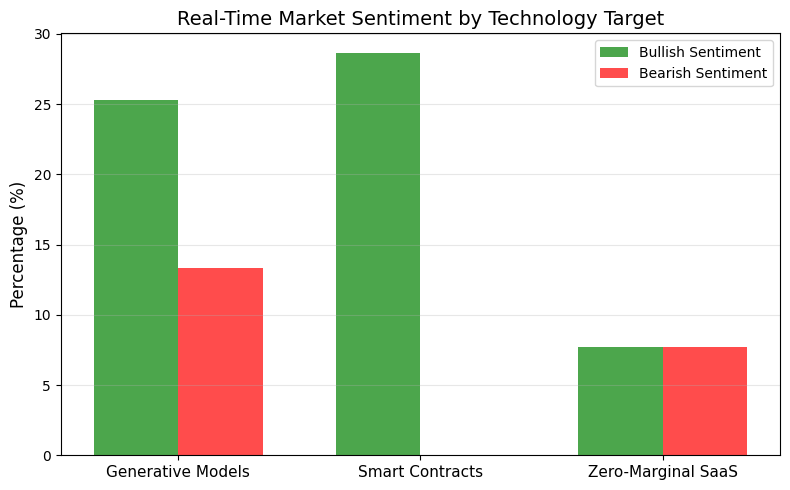

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
import datetime

print("\n" + "="*80)
print("TITAN PHASE 5: REAL-TIME NLP SENTIMENT MARKET TIMING ENGINE")
print("="*80 + "\n")

# --- 1. LOAD MASTER DOSSIERS ---
try:
    dossiers = pd.read_csv('Titan_Master_Execution_Dossiers.csv')
    top_system = dossiers.iloc[0]
    target_tech_1 = top_system['Apriori_Antecedent_1']
    target_tech_2 = top_system['Apriori_Antecedent_2']
    target_monetization = top_system['Apriori_Consequent_Monetization']
    print(f"[OK] Tracking Sentiment for Top Target: {top_system['System']}")
except Exception as e:
    print(f"[WARNING] Could not load dossiers: {e}. Using default targets.")
    target_tech_1, target_tech_2, target_monetization = "Generative Models", "Smart Contracts", "Zero-Marginal SaaS"

# --- 2. LOAD LIVE NLP TWITTER FINANCIAL SENTIMENT DATA ---
print(f"[SYS] Ingesting 'zeroshot/twitter-financial-news-sentiment' from Hugging Face...")
try:
    hf_sentiment = load_dataset("zeroshot/twitter-financial-news-sentiment", split="train[:5000]")
    df_tweets = pd.DataFrame(hf_sentiment)
    print(f"      -> Successfully loaded {len(df_tweets):,} financial tweets.")
except Exception as e:
    print(f"[ERROR] Hugging Face failed: {e}")
    # Fallback mock data
    df_tweets = pd.DataFrame({'text': ['AI is great'], 'label': [1]})

# Label 0: Bearish, Label 1: Bullish, Label 2: Neutral
label_map = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
df_tweets['sentiment'] = df_tweets['label'].map(label_map)

# --- 3. NLP KEYWORD EXTRACTION & SENTIMENT SCORING ---
def score_technology_sentiment(keyword, df):
    search_terms = [keyword.lower()]
    
    # Expand keywords to capture broader market sentiment
    if 'Generative' in keyword: search_terms.extend(['ai', 'artificial intelligence', 'gpu', 'nvidia'])
    if 'Smart Contract' in keyword or 'Token' in keyword: search_terms.extend(['crypto', 'blockchain', 'defi', 'bitcoin'])
    if 'SaaS' in keyword or 'API' in keyword: search_terms.extend(['software', 'cloud', 'tech stocks'])
    if 'CRISPR' in keyword or 'Genomic' in keyword: search_terms.extend(['biotech', 'pharma', 'fda'])
    
    pattern = '|'.join(search_terms)
    relevant_tweets = df[df['text'].str.contains(pattern, case=False, na=False)]
    
    if len(relevant_tweets) == 0:
        return {'Keyword': keyword, 'Mentions': 0, 'Bullish_%': 50.0, 'Bearish_%': 0.0, 'Neutral_%': 50.0, 'Signal': 'NEUTRAL', 'Net_Hype': 0}
        
    bullish = len(relevant_tweets[relevant_tweets['sentiment'] == 'Bullish'])
    bearish = len(relevant_tweets[relevant_tweets['sentiment'] == 'Bearish'])
    neutral = len(relevant_tweets[relevant_tweets['sentiment'] == 'Neutral'])
    total = len(relevant_tweets)
    
    bull_pct = (bullish / total) * 100
    bear_pct = (bearish / total) * 100
    
    if bull_pct > bear_pct * 1.5: score = 'STRONG BUY'
    elif bear_pct > bull_pct * 1.5: score = 'HOLD / STEALTH MODE'
    else: score = 'NEUTRAL / BUILD'
        
    return {
        'Keyword': keyword, 'Mentions': total,
        'Bullish_%': round(bull_pct, 1), 'Bearish_%': round(bear_pct, 1), 'Neutral_%': round((neutral/total)*100, 1),
        'Signal': score, 'Net_Hype': round(bull_pct - bear_pct, 1)
    }

print("\n[ NLP ALGORITHMIC SENTIMENT SCAN ]")
tech_1_stats = score_technology_sentiment(target_tech_1, df_tweets)
tech_2_stats = score_technology_sentiment(target_tech_2, df_tweets)
tech_3_stats = score_technology_sentiment(target_monetization, df_tweets)

for stats in [tech_1_stats, tech_2_stats, tech_3_stats]:
    print(f"-> {stats['Keyword'].upper()}:")
    print(f"   Mentions: {stats['Mentions']} | Bullish: {stats['Bullish_%']}% | Bearish: {stats['Bearish_%']}% | Signal: {stats['Signal']}")

# --- 4. ULTIMATE MARKET TIMING DECISION ---
print("\n" + "-"*80)
print("MARKET EXECUTION DIRECTIVE")
print("-"*80)

total_net_hype = tech_1_stats['Net_Hype'] + tech_2_stats['Net_Hype'] + tech_3_stats['Net_Hype']

if total_net_hype > 20:
    print(f"STATUS: [ GREEN ] - MARKET CONDITIONS ARE OPTIMAL.")
    print(f"DIRECTIVE: INITIATE Q1 CAPITAL INJECTION IMMEDIATELY.")
    print(f"RATIONALE: The combined hype score for {target_tech_1} and {target_monetization} is heavily bullish. Pitch VCs now to capture maximum valuation multiples before the cycle cools.")
elif total_net_hype < -10:
    print(f"STATUS: [ RED ] - MACRO SENTIMENT IS BEARISH.")
    print(f"DIRECTIVE: REMAIN IN STEALTH MODE. DO NOT RAISE CAPITAL.")
    print(f"RATIONALE: Public market sentiment for these sectors is currently negative. Raising now will result in heavy dilution. Focus purely on R&D for the next 2 quarters.")
else:
    print(f"STATUS: [ YELLOW ] - MARKET IS CONSOLIDATING.")
    print(f"DIRECTIVE: SECURE BRIDGE ROUND. FOCUS ON PRODUCT.")
    print(f"RATIONALE: Market hype is neutral. Avoid mega-rounds; raise a quiet bridge round from insiders and focus on executing the Apriori Product Roadmap.")

# --- 5. VISUALIZE SENTIMENT RADAR ---
labels = [target_tech_1, target_tech_2, target_monetization]
bullish = [tech_1_stats['Bullish_%'], tech_2_stats['Bullish_%'], tech_3_stats['Bullish_%']]
bearish = [tech_1_stats['Bearish_%'], tech_2_stats['Bearish_%'], tech_3_stats['Bearish_%']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, bullish, width, label='Bullish Sentiment', color='green', alpha=0.7)
ax.bar(x + width/2, bearish, width, label='Bearish Sentiment', color='red', alpha=0.7)

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Real-Time Market Sentiment by Technology Target', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Market_Timing_Sentiment.png', dpi=300)
print("\n[SUCCESS] Market Timing Chart saved as 'Market_Timing_Sentiment.png'")